# Лабораторная работа по физике "Кольца Ньютона"

In [125]:
# --------------------------- Подключение библиотек -------------------------- #
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["text.usetex"] = False

In [126]:
# --------------------------------- Константы -------------------------------- #
# Угол преломления и погрешность (получен по измерениям транспортира) (Градус)
beta = 22
delta_beta = 0.5

# Показатель преломления среды
n = 1

# Длина волны света
lambda_light = 0.589 * 1e-6

# Абсолютная погрешность диаметра колец Ньютона
delta_d = 5 * 1e-6

In [127]:
# --------------------------- Результаты измерений --------------------------- #
tests = [
    [
        31.31,
        31.43,
        31.55,
        31.72,
        31.89,
        32.03,
        32.22,
        32.46,
        32.74,
        33.06,
        34.06,
        35.00,
        35.31,
        35.53,
        35.71,
        35.88,
        36.05,
        36.20,
        36.36,
        36.48
    ],
    [
        31.2,
        31.43,
        31.59,
        31.71,
        31.86,
        32.02,
        32.22,
        32.45,
        32.73,
        33.09,
        34.62,
        34.99,
        35.26,
        35.5,
        35.69,
        35.87,
        36.03,
        36.18,
        36.34,
        36.48,
    ],
    [
        31.2,
        31.43,
        31.57,
        31.72,
        31.9,
        32.04,
        32.26,
        32.47,
        32.74,
        33.08,
        34.63,
        35.02,
        35.29,
        35.56,
        35.75,
        35.91,
        36.06,
        36.19,
        36.36,
        36.49,
    ],
    [
        31.28,
        31.43,
        31.58,
        31.71,
        31.89,
        32.02,
        32.21,
        32.47,
        32.77,
        33.07,
        34.61,
        35.02,
        35.27,
        35.5,
        35.69,
        35.89,
        36.04,
        36.17,
        36.33,
        36.49,
    ],
]

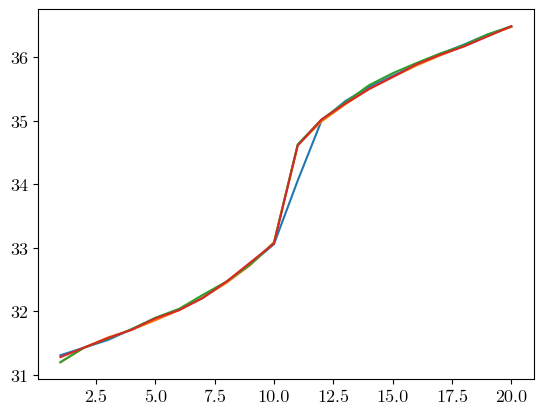

In [128]:
plt.plot([i+1 for i in range(20)], tests[0])
plt.plot([i+1 for i in range(20)], tests[1])
plt.plot([i+1 for i in range(20)], tests[2])
plt.plot([i+1 for i in range(20)], tests[3])

In [129]:
def diameter_ring(l1: float, l2: float) -> float:
    """Нахождение диаметра кольца Ньютона по показаниям микрометра"""
    diameter = abs(l1 - l2)
    return diameter


def error_diameter_ring(diameter: float, delta_diameter: float) -> float:
    """Нахождение абсолютной погрешности диаметра кольца Ньютона по показаниям микрометра"""
    error_diameter = 2 * diameter * delta_diameter
    return error_diameter

## Диаметр колец Ньютона

In [130]:
diameters_rings = []

for test in tests:
    diameters_rings.append(
        [diameter_ring(test[k], test[-k - 1]) for k in range(len(test) // 2)]
    )

diameters_rings

[[5.169999999999998,
  4.93,
  4.650000000000002,
  4.329999999999998,
  3.990000000000002,
  3.6799999999999997,
  3.3100000000000023,
  2.8500000000000014,
  2.259999999999998,
  1.0],
 [5.279999999999998,
  4.910000000000004,
  4.59,
  4.32,
  4.009999999999998,
  3.6699999999999946,
  3.280000000000001,
  2.809999999999995,
  2.260000000000005,
  1.529999999999994],
 [5.290000000000003,
  4.93,
  4.619999999999997,
  4.340000000000003,
  4.009999999999998,
  3.710000000000001,
  3.3000000000000043,
  2.8200000000000003,
  2.280000000000001,
  1.5500000000000043],
 [5.210000000000001,
  4.899999999999999,
  4.590000000000003,
  4.329999999999998,
  4.0,
  3.6699999999999946,
  3.289999999999999,
  2.8000000000000043,
  2.25,
  1.5399999999999991]]

## Квадрат диметра колец Ньютона

In [131]:
square_diameters_rings = []

for diameters in diameters_rings:
    square_diameters_rings.append([diameter**2 for diameter in diameters])

square_diameters_rings

[[26.72889999999998,
  24.304899999999996,
  21.62250000000002,
  18.748899999999985,
  15.920100000000016,
  13.542399999999997,
  10.956100000000015,
  8.122500000000008,
  5.107599999999991,
  1.0],
 [27.878399999999974,
  24.108100000000036,
  21.068099999999998,
  18.6624,
  16.080099999999984,
  13.46889999999996,
  10.758400000000007,
  7.896099999999973,
  5.107600000000023,
  2.3408999999999818],
 [27.98410000000003,
  24.304899999999996,
  21.344399999999975,
  18.835600000000028,
  16.080099999999984,
  13.764100000000006,
  10.890000000000029,
  7.952400000000002,
  5.198400000000005,
  2.402500000000013],
 [27.14410000000001,
  24.009999999999987,
  21.06810000000003,
  18.748899999999985,
  16.0,
  13.46889999999996,
  10.824099999999994,
  7.840000000000024,
  5.0625,
  2.3715999999999973]]

## Погрешность квадрата диаметра колец Ньютона

In [132]:
errors_square_diameters_rings = []

for diameters in diameters_rings:
    errors_square_diameters_rings.append(
        [
            error_diameter_ring(diameter=diameter, delta_diameter=delta_d)
            for diameter in diameters
        ]
    )

errors_square_diameters_rings

[[5.1699999999999976e-05,
  4.929999999999999e-05,
  4.650000000000002e-05,
  4.329999999999998e-05,
  3.9900000000000014e-05,
  3.679999999999999e-05,
  3.310000000000002e-05,
  2.8500000000000012e-05,
  2.2599999999999977e-05,
  9.999999999999999e-06],
 [5.279999999999997e-05,
  4.9100000000000035e-05,
  4.59e-05,
  4.32e-05,
  4.009999999999998e-05,
  3.669999999999994e-05,
  3.280000000000001e-05,
  2.8099999999999948e-05,
  2.2600000000000048e-05,
  1.5299999999999938e-05],
 [5.2900000000000025e-05,
  4.929999999999999e-05,
  4.619999999999997e-05,
  4.340000000000003e-05,
  4.009999999999998e-05,
  3.710000000000001e-05,
  3.3000000000000036e-05,
  2.82e-05,
  2.280000000000001e-05,
  1.550000000000004e-05],
 [5.2100000000000006e-05,
  4.8999999999999985e-05,
  4.590000000000003e-05,
  4.329999999999998e-05,
  3.9999999999999996e-05,
  3.669999999999994e-05,
  3.2899999999999987e-05,
  2.800000000000004e-05,
  2.2499999999999998e-05,
  1.539999999999999e-05]]

In [133]:
def radius_lens(
    diameter: float, k: int, lam: float = lambda_light, beta: float = beta, n: float = n
) -> float:
    """Вычисление радиуса линзы"""
    radius = (n * math.cos(math.radians(beta))) / (4 * lam) * (diameter**2) / k
    return radius


def error_radius_lens(
    diameter: float,
    k: int,
    lam: float = lambda_light,
    beta: float = beta,
    n: float = n,
    delta_beta: float = delta_beta,
    delta_diameter: float = delta_d,
) -> float:
    """Вычисление погрешности радиуса линзы"""
    first = n / (4 * lam * k)
    second = 2 * diameter * delta_diameter * math.cos(math.radians(beta))
    three = diameter**2 * delta_beta * math.sin(math.radians(beta))
    error_radius = first * (second + three)
    return error_radius

## Радиус линзы

In [134]:
radius_lenses = []

for diameters in diameters_rings:
    radius_lenses.append(
        [
            radius_lens(diameter * 1e-3, k + 1) * 1e3
            for k, diameter in enumerate(diameters[::-1])
        ]
    )

radius_lenses

[[393.54153419642927,
  1005.0263700308395,
  1065.5137038368332,
  1077.9201007023762,
  1065.8993745403448,
  1044.203429760097,
  1054.0672672136327,
  1063.6689778952878,
  1062.7764038323103,
  1051.8932313382934],
 [921.2413774004141,
  1005.0263700308457,
  1035.8144360561382,
  1058.4693103747172,
  1060.1143139876542,
  1054.6978706719997,
  1049.204218255349,
  1036.3965495754742,
  1054.1709622845503,
  1097.1308306941726],
 [945.4835359069267,
  1022.8931556833601,
  1043.199898847895,
  1071.4168268497815,
  1083.349006166615,
  1054.6978706719997,
  1058.9415602157537,
  1049.9884903127818,
  1062.7764038323103,
  1101.290564710631],
 [933.3231025002509,
  996.1520084347119,
  1028.4552093666719,
  1064.933230073892,
  1060.1143139876542,
  1049.444091190478,
  1054.0672672136327,
  1036.396549575476,
  1049.8813595618071,
  1068.2330758381302]]

## Погрешность радиуса линзы

In [135]:
error_radius_lenses = []

for diameters in diameters_rings:
    error_radius_lenses.append(
        [
            error_radius_lens(diameter * 1e-3, k + 1) * 1e3
            for k, diameter in enumerate(diameters[::-1])
        ]
    )

error_radius_lenses

[[83.43596572734461,
  207.47552491060355,
  218.98638474328345,
  221.01055121479203,
  218.22211639948054,
  213.55983656745533,
  215.3697453644516,
  217.16254150600267,
  216.8505027441682,
  214.53083585137458],
 [192.1240238703407,
  207.4755249106048,
  212.934271002973,
  217.0517208969298,
  217.04558747813098,
  215.69296929553826,
  214.381723684201,
  211.6236377492309,
  215.10334534164832,
  223.7127136869356],
 [197.09996608092194,
  211.12420405152,
  214.4393493830126,
  219.68696608131899,
  221.77078329562028,
  215.69296929553826,
  216.36003848899955,
  214.38414581569808,
  216.8505027441682,
  224.55696991985147],
 [194.60404492059277,
  205.6631104227038,
  211.4344926596279,
  218.36735597536423,
  217.04558747813098,
  214.6250779223237,
  215.3697453644516,
  211.62363774923125,
  214.23241665873397,
  217.84744036474368]]

## Аппроксимация квадрата диаметра

In [136]:
def approx_line(x_data: float, y_data: float) -> tuple[float, float]:
    """Аппроксимирование данных методом наименьших квадратов для линейной функции"""
    l = len(x_data)
    s_x = sum(x_data)
    s_y = sum(y_data)
    s_xx = sum([i**2 for i in x_data])
    s_xy = sum([i * j for i, j in zip(x_data, y_data)])
    
    k = (l * s_xy - s_x * s_y) / (l * s_xx - s_x**2)
    b = (s_xx * s_y - s_x * s_xy) / (l * s_xx - s_x**2)
    
    return k, b

In [137]:
middle_square_diameters = []

count_row = len(square_diameters_rings[0])
count_col = len(square_diameters_rings)

for index in range(count_row):
    middle_square_diameters.append(sum([square_diameters_rings[i][index] for i in range(count_col)]) / count_col)

middle_square_diameters

[27.433874999999997,
 24.181975000000005,
 21.275775000000007,
 18.74895,
 16.020074999999995,
 13.561074999999981,
 10.857150000000011,
 7.952750000000002,
 5.119025000000004,
 2.028749999999998]

In [138]:
k_square_diameters, b_square_diameters = approx_line([i for i in range(10, 0, -1)], middle_square_diameters)

k_square_diameters, b_square_diameters

(2.756583636363634, -0.4432699999999904)

[0.85, 10.15]


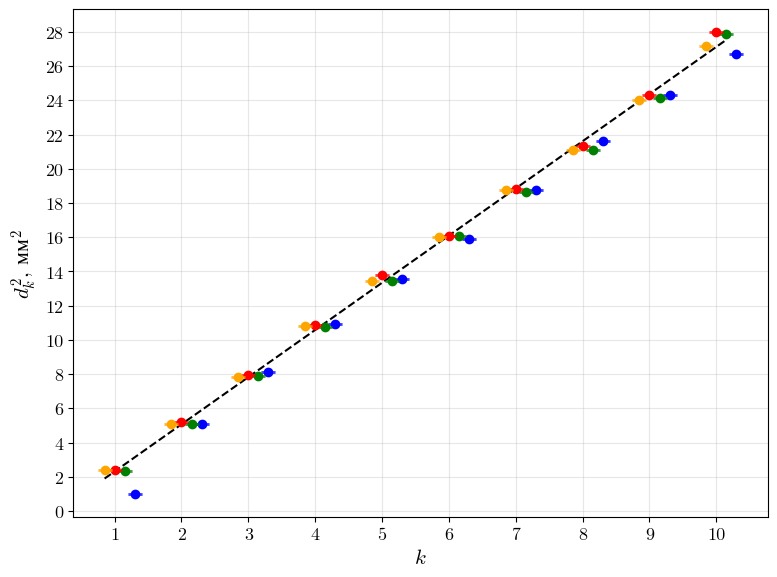

In [139]:
fig, ax = plt.subplots(figsize=(8, 6))  # + явный размер

step = 0.15

colors = [
    "blue",
    "green",
    "red",
    "orange"
]
trend = lambda x: k_square_diameters * x + b_square_diameters

x_trend = [1-step, 10+step]
y_trend = [trend(i) for i in x_trend]

print(x_trend)
plt.plot(x_trend, y_trend, '--', color='black')

y_points = [i + 1 for i in range(10)][::-1]

length = len(square_diameters_rings)

for index_test, (diameters, error_diameters) in enumerate(
    zip(square_diameters_rings, errors_square_diameters_rings)
):
    window_y = [y - step * (index_test - length // 2) for y in y_points]
    ax.plot(window_y, diameters, "o", color=colors[index_test])
    ax.errorbar(
        window_y,
        diameters,
        yerr=error_diameters,
        fmt="none",
        capsize=5,
        capthick=2,
        elinewidth=2,
        color=colors[index_test],
        alpha=0.5,
    )


plt.xlabel("$k$")
plt.ylabel(r"$d_k^2$, $\text{мм}^2$")
plt.xticks(y_points)
plt.yticks(np.arange(0, 30, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('graph_1.pdf', bbox_inches='tight')
plt.show()

In [140]:
middle = 0
count = 0

for row in radius_lenses:
    count += len(row)
    middle += sum(row)
    
middle_radius_lenses = middle / count

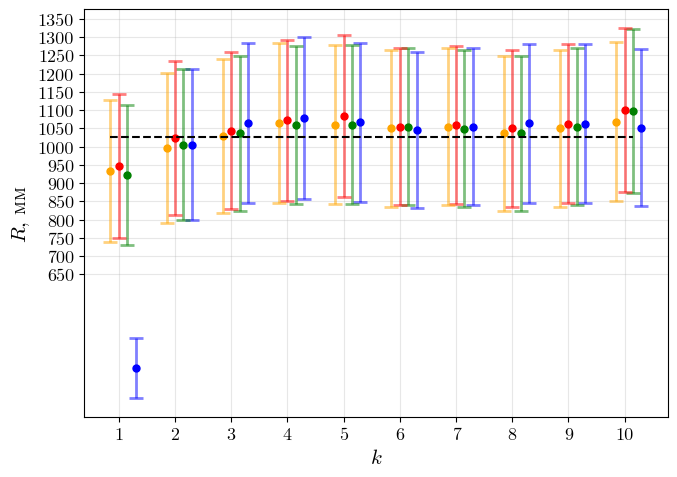

In [141]:
fig, ax = plt.subplots(figsize=(7, 5))

step = 0.15

y_points = [i for i in range(1, 11)]

colors = [
    'blue', 
    'green',
    'red', 
    'orange'
]

length = len(radius_lenses)
for index, (r, de_r, col) in enumerate(zip(radius_lenses, error_radius_lenses, colors)):
    window_y = [y - step * (index - length // 2) for y in y_points]
    ax.plot(window_y, r, 'o', markersize=5, color=col, label=f"Измерение {index+1}")
    ax.errorbar(window_y, r,
                yerr=de_r,
                fmt='none',
                capsize=5,
                capthick=2,
                elinewidth=2,
                ecolor=col,
                alpha=0.5)
    
plt.plot([1-step, 10+step], [middle_radius_lenses] * 2, '--', color='black')

plt.xlabel("$k$")
plt.ylabel("$R$, мм")
plt.xticks(y_points)
plt.yticks([i for i in range(650, 1400, 50)])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('graph_2.pdf', bbox_inches='tight')
plt.show()